In [49]:
2+2

4

In [50]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchinfo import summary
import torch
import torch.nn as nn
from tqdm import tqdm


transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)   

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=True)

test_loader = DataLoader(test_dataset,
                         batch_size=64,
                         shuffle=False)

In [51]:
# shapes of the data
for images, labels in train_loader:
    print(f"Images batch shape: {images.size()}")
    print(f"Labels batch shape: {labels.size()}")
    break

# total number of samples in the training and test datasets
print(f"Total training samples: {len(train_dataset)}")
print(f"Total test samples: {len(test_dataset)}")

Images batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
Total training samples: 60000
Total test samples: 10000


In [52]:


class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x= self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [53]:
summary(FashionMLP(), input_size=(64, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
FashionMLP                               [64, 10]                  --
├─Flatten: 1-1                           [64, 784]                 --
├─Linear: 1-2                            [64, 256]                 200,960
├─ReLU: 1-3                              [64, 256]                 --
├─Linear: 1-4                            [64, 128]                 32,896
├─ReLU: 1-5                              [64, 128]                 --
├─Linear: 1-6                            [64, 10]                  1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 15.05
Input size (MB): 0.20
Forward/backward pass size (MB): 0.20
Params size (MB): 0.94
Estimated Total Size (MB): 1.34

In [54]:
model = FashionMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []
test_losses = []



In [55]:
epochs = 10

for epoch in tqdm(range(epochs), desc="Training Progress (epochs)"):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch [{epoch + 1}/{epochs}], "
          f"Train Loss: {train_losses[-1]:.4f}, "
          f"Test Loss: {test_losses[-1]:.4f}")

Training Progress (epochs):   0%|          | 0/10 [00:00<?, ?it/s]

Training Progress (epochs):  10%|█         | 1/10 [00:12<01:50, 12.28s/it]

Epoch [1/10], Train Loss: 0.5217, Test Loss: 0.4528


Training Progress (epochs):  20%|██        | 2/10 [00:25<01:43, 12.97s/it]

Epoch [2/10], Train Loss: 0.3726, Test Loss: 0.3886


...

Epoch [8/10], Train Loss: 0.2510, Test Loss: 0.3415


Training Progress (epochs):  90%|█████████ | 9/10 [02:34<00:18, 18.59s/it]

Epoch [9/10], Train Loss: 0.2417, Test Loss: 0.3242


Training Progress (epochs): 100%|██████████| 10/10 [02:52<00:00, 17.27s/it]

Epoch [10/10], Train Loss: 0.2295, Test Loss: 0.3361


In [61]:
model.eval()
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8844


In [57]:
import random
import matplotlib.pyplot as plt
import torch

classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

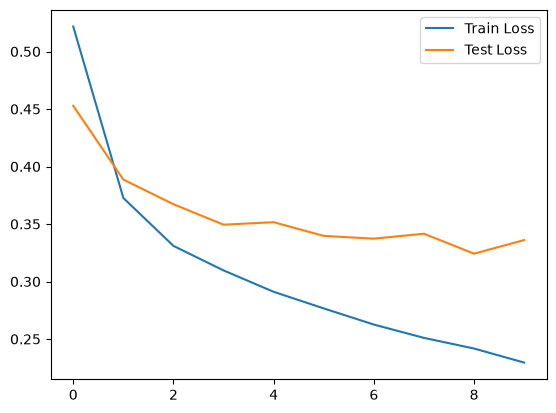

In [58]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()

In [59]:
def show_predictions(model, dataset, n=12):
    """
    Display n random images from a dataset with
    actual and predicted labels.
    """
    print([(i, class_label) for i, class_label in enumerate(classes)])
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                             figsize=(2 * cols, 2 * rows))
    axes = axes.flatten()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image, label = dataset[idx]
            # Add batch dimension
            logits = model(image.unsqueeze(0))
            probabilities = torch.softmax(logits, dim=1)
            confidence = probabilities.max().item() * 100
            prediction = logits.argmax(dim=1).item()
            ax.imshow(image.squeeze(), cmap="gray")
            colour = "green" if prediction == label else "red"
            # print probabilities if prediction is incorrect
            if prediction != label:
                print(f"Image index: {idx}")
                print(f"Actual: {classes[label]}")
                print(f"Predicted: {classes[prediction]}")
                print(f"Confidence: {confidence:.2f}%")
                # probabilities of the predicted class, and the actual class
                print(f" probability of predicted class: {probabilities[0, prediction].item():.2f}")
                print(f" probability of actual class: {probabilities[0, label].item():.2f}")
                print(f"Probabilities: {[f'{p*100:.2f}%' for p in probabilities.squeeze().tolist()]}")
            ax.set_title(
                f"Actual: {classes[label]}\n"
                f"Pred: {classes[prediction]}\n"
                f"Conf: {confidence:.2f}%",
                color=colour,
                fontsize=10,
            )
            ax.axis("off")

    # Hide unused axes
    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

[(0, 'T-shirt'), (1, 'Trouser'), (2, 'Pullover'), (3, 'Dress'), (4, 'Coat'), (5, 'Sandal'), (6, 'Shirt'), (7, 'Sneaker'), (8, 'Bag'), (9, 'Ankle boot')]
Image index: 4568
Actual: Ankle boot
Predicted: Sneaker
Confidence: 94.66%
 probability of predicted class: 0.95
 probability of actual class: 0.05
Probabilities: ['0.00%', '0.00%', '0.00%', '0.00%', '0.00%', '0.03%', '0.00%', '94.66%', '0.00%', '5.30%']
Image index: 1905
Actual: T-shirt
Predicted: Shirt
Confidence: 59.28%
 probability of predicted class: 0.59
 probability of actual class: 0.41
Probabilities: ['40.69%', '0.00%', '0.01%', '0.01%', '0.00%', '0.00%', '59.28%', '0.00%', '0.00%', '0.00%']


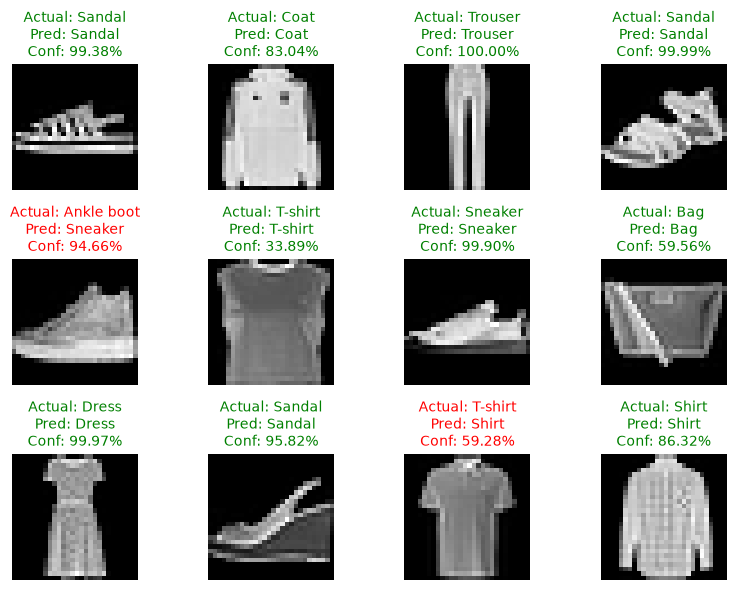

In [60]:
show_predictions(model, test_dataset, n=12)